# The Convolution Operation

**Math prerequisites:** `00_math/linear_algebra.ipynb`, `00_math/matrix_calculus.ipynb`  
**Code prerequisites:** `01_foundations/backpropagation.ipynb`, `01_foundations/pytorch_fundamentals.ipynb`

**Paper → Code:** LeCun et al. — *Gradient-Based Learning Applied to Document Recognition* (1998)

**What you will build:**
- 2D convolution from scratch in NumPy — every multiplication shown
- The full math: output size formula, padding, stride, dilation, groups
- Animated sliding filter visualization
- Receptive field analysis — why depth matters in CNNs
- Transposed convolution (deconv) — used in segmentation and GANs
- Depthwise separable convolution — the core of MobileNet
- Full backward pass for `nn.Conv2d`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/02_cnn/convolution_operation.ipynb)

---

## Table of Contents
1. [Why Convolution? — the inductive biases](#1-why-convolution)
2. [The Convolution Operation — full math](#2-convolution-math)
3. [Output Size Formula](#3-output-size)
4. [Padding, Stride, Dilation](#4-padding-stride-dilation)
5. [Code Layer 1 — NumPy from Scratch](#5-numpy-scratch)
6. [Code Layer 2 — PyTorch nn.Conv2d](#6-pytorch)
7. [Receptive Field](#7-receptive-field)
8. [Visualising Learned Filters](#8-filter-visualisation)
9. [Transposed Convolution](#9-transposed-convolution)
10. [Depthwise Separable Convolution](#10-depthwise-separable)
11. [Training Dashboard](#11-training-dashboard)
12. [Debugging Section](#12-debugging)
13. [Exercises](#13-exercises)


## Setup

In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')


PyTorch 2.10.0+cpu | device: cpu


## 1. Why Convolution? — The Inductive Biases

A fully connected layer applied to a 224×224×3 image requires $224 \times 224 \times 3 = 150{,}528$ input features. A first hidden layer of 4096 neurons needs $150{,}528 \times 4{,}096 \approx 617M$ parameters — just in the first layer. This is infeasible and would overfit immediately.

Convolution encodes two powerful **inductive biases** that reduce parameters dramatically:

### 1. Translation Equivariance

If a pattern appears in the top-left of an image, the same filter should detect it anywhere in the image. The filter is **shared** across all spatial positions — one set of weights detects the pattern everywhere.

Formally: if $T_\delta$ is a translation by $\delta$, then $f(T_\delta(x)) = T_\delta(f(x))$.

### 2. Locality

Pixels interact strongly with their neighbors and weakly with distant pixels. A filter connects each output to only a small local region (the **receptive field**), not to the entire image.

### Parameter count comparison

| Layer | Parameters | For 3→64 channels, 3×3 filter on 224×224 |
|---|---|---|
| Fully connected | $H \times W \times C_{in} \times C_{out}$ | $224^2 \times 3 \times 64 \approx 9.7B$ |
| Conv2d | $k \times k \times C_{in} \times C_{out}$ | $3 \times 3 \times 3 \times 64 = 1{,}728$ |

**5600× fewer parameters** — and the conv layer generalises better because of weight sharing.


In [13]:
# Parameter count comparison
H, W, C_in, C_out, k = 224, 224, 3, 64, 3

params_fc   = H * W * C_in * C_out
params_conv = k * k * C_in * C_out

print('Parameter count comparison:')
print(f'  Fully connected (224×224×3 → 64): {params_fc:>15,}')
print(f'  Conv2d (3×3, 3→64):               {params_conv:>15,}')
print(f'  Reduction factor:                 {params_fc/params_conv:>15,.0f}×')

# PyTorch verification
fc   = nn.Linear(H*W*C_in, C_out)
conv = nn.Conv2d(C_in, C_out, kernel_size=k, padding=1)
print(f'\nnn.Linear params: {sum(p.numel() for p in fc.parameters()):,}')
print(f'nn.Conv2d params: {sum(p.numel() for p in conv.parameters()):,}')


Parameter count comparison:
  Fully connected (224×224×3 → 64):       9,633,792
  Conv2d (3×3, 3→64):                         1,728
  Reduction factor:                           5,575×

nn.Linear params: 9,633,856
nn.Conv2d params: 1,792


## 2. The Convolution Operation — Full Math

### 2D Cross-Correlation (what CNNs actually compute)

For a single input channel, a kernel $W \in \mathbb{R}^{k_h \times k_w}$, and input feature map $X \in \mathbb{R}^{H \times W}$:

$$Y[i, j] = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} X[i+m,\, j+n] \cdot W[m, n] + b$$

Each output element is the **dot product** between the kernel and a local patch of the input.

> Note: In mathematics, convolution flips the kernel. CNNs use **cross-correlation** (no flip) because the filters are learned anyway — flipping doesn't change what can be learned.

### Multi-channel (the general case)

For $C_{\text{in}}$ input channels and $C_{\text{out}}$ output channels:

$$Y[c_{\text{out}}, i, j] = \sum_{c_{\text{in}}=0}^{C_{\text{in}}-1} \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} X[c_{\text{in}}, i+m, j+n] \cdot W[c_{\text{out}}, c_{\text{in}}, m, n] + b[c_{\text{out}}]$$

- Kernel $W \in \mathbb{R}^{C_{\text{out}} \times C_{\text{in}} \times k_h \times k_w}$
- Each output channel uses a different set of $C_{\text{in}}$ kernels
- Each kernel detects one specific feature across all input channels

### Batch dimension

In practice, inputs have a batch dimension: $X \in \mathbb{R}^{N \times C_{\text{in}} \times H \times W}$, $Y \in \mathbb{R}^{N \times C_{\text{out}} \times H' \times W'}$.

The convolution is applied independently to each sample in the batch.


/tmp/ipykernel_10583/2280635402.py:60: UserWarning: Glyph 8857 (\N{CIRCLED DOT OPERATOR}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8857 (\N{CIRCLED DOT OPERATOR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


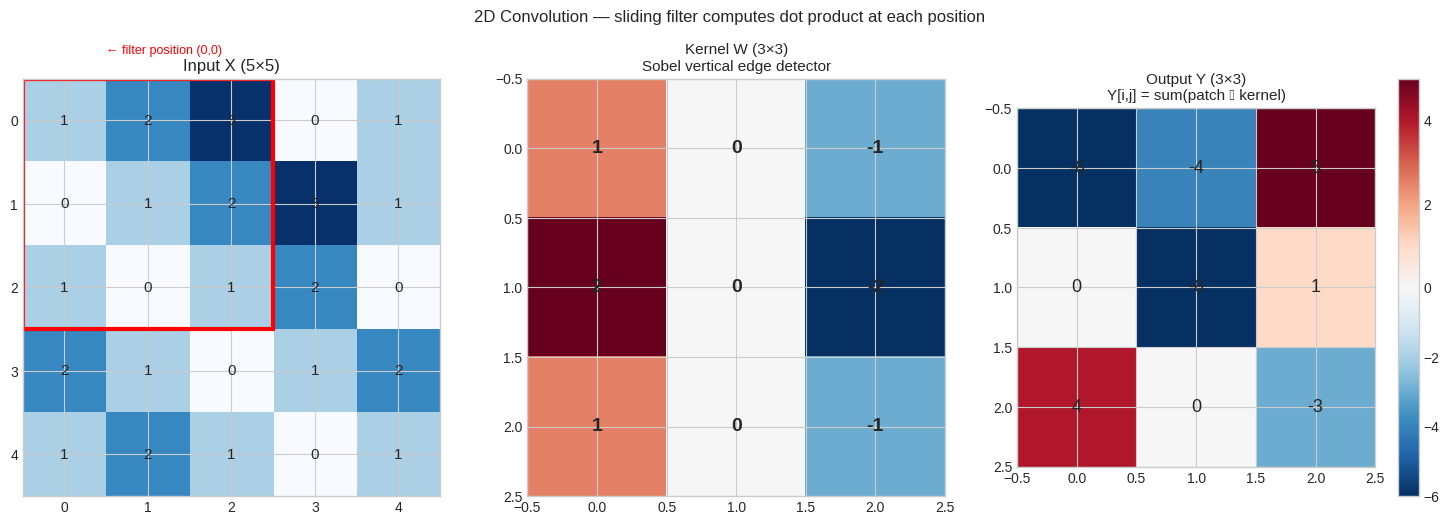

Y[0,0] = sum(X[0:3,0:3] ⊙ W):
  Patch: [1. 2. 3. 0. 1. 2. 1. 0. 1.]
  Kernel:[ 1.  0. -1.  2.  0. -2.  1.  0. -1.]
  Dot:    -6.0


In [14]:
# Visualise the sliding filter operation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Input
X_vis = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 0, 1, 2, 0],
    [2, 1, 0, 1, 2],
    [1, 2, 1, 0, 1],
], dtype=float)

# Kernel
W_vis = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1],
], dtype=float)  # Sobel vertical edge detector

# Manual convolution
H_in, W_in = X_vis.shape
k          = 3
H_out = H_in - k + 1  # 3
W_out = W_in - k + 1  # 3
Y_vis = np.zeros((H_out, W_out))
for i in range(H_out):
    for j in range(W_out):
        patch = X_vis[i:i+k, j:j+k]
        Y_vis[i, j] = np.sum(patch * W_vis)

# Draw
norm_div = TwoSlopeNorm(vmin=Y_vis.min(), vcenter=0, vmax=Y_vis.max()) \
    if Y_vis.min() < 0 < Y_vis.max() else None

im0 = axes[0].imshow(X_vis, cmap='Blues', vmin=0, vmax=3)
for i in range(H_in):
    for j in range(W_in):
        axes[0].text(j, i, f'{X_vis[i,j]:.0f}', ha='center', va='center', fontsize=11)
axes[0].set_title('Input X (5×5)', fontsize=12)
axes[0].add_patch(mpatches.Rectangle((-0.5,-0.5), 3, 3,
    fill=False, edgecolor='red', linewidth=3))
axes[0].text(0.5, -0.8, '← filter position (0,0)', color='red', fontsize=9)

im1 = axes[1].imshow(W_vis, cmap='RdBu_r')
for i in range(k):
    for j in range(k):
        axes[1].text(j, i, f'{W_vis[i,j]:.0f}', ha='center', va='center',
                     fontsize=14, fontweight='bold')
axes[1].set_title('Kernel W (3×3)\nSobel vertical edge detector', fontsize=11)

im2 = axes[2].imshow(Y_vis, cmap='RdBu_r', norm=norm_div if norm_div else None)
plt.colorbar(im2, ax=axes[2])
for i in range(H_out):
    for j in range(W_out):
        axes[2].text(j, i, f'{Y_vis[i,j]:.0f}', ha='center', va='center', fontsize=13)
axes[2].set_title(f'Output Y ({H_out}×{W_out})\nY[i,j] = sum(patch ⊙ kernel)', fontsize=11)

plt.suptitle('2D Convolution — sliding filter computes dot product at each position',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print('Y[0,0] = sum(X[0:3,0:3] ⊙ W):')
print(f'  Patch: {X_vis[0:3,0:3].ravel()}')
print(f'  Kernel:{W_vis.ravel()}')
print(f'  Dot:    {np.sum(X_vis[0:3,0:3]*W_vis)}')


## 3. Output Size Formula

Given input size $H_{\text{in}}$, kernel $k$, padding $p$, stride $s$, dilation $d$:

$$H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2p - d(k-1) - 1}{s} \right\rfloor + 1$$

**Intuition for each parameter:**

| Parameter | Effect on output size | Typical value |
|---|---|---|
| Padding $p$ | Increases: adds $2p$ to input | 0 (valid) or $\lfloor k/2 \rfloor$ (same) |
| Stride $s$ | Decreases: subsamples output | 1 (full resolution) or 2 (halve) |
| Kernel $k$ | Decreases: larger filter reduces output | 3 (most common) |
| Dilation $d$ | Decreases: spreads filter out | 1 (standard) |

### The 'same' padding trick

To get $H_{\text{out}} = H_{\text{in}}$ (same spatial size) with stride 1:

$$p = \frac{k-1}{2} \quad \text{(requires odd } k\text{)}$$

For $k=3$: $p=1$. For $k=5$: $p=2$. For $k=7$: $p=3$.


In [15]:
def output_size(H_in, k, p=0, s=1, d=1):
    return (H_in + 2*p - d*(k-1) - 1) // s + 1

H = 28   # input size (MNIST)
print(f'Input: {H}×{H}')
print()
print(f'{'Config':<35} {'H_out':>6} {'Notes'}')
print('-' * 70)
configs_os = [
    (dict(k=3, p=0, s=1, d=1), 'k=3 p=0 s=1 (valid conv)'),
    (dict(k=3, p=1, s=1, d=1), 'k=3 p=1 s=1 (same conv)'),
    (dict(k=3, p=0, s=2, d=1), 'k=3 p=0 s=2 (stride-2, halves size)'),
    (dict(k=3, p=1, s=2, d=1), 'k=3 p=1 s=2 (same padding + stride)'),
    (dict(k=5, p=2, s=1, d=1), 'k=5 p=2 s=1 (same for k=5)'),
    (dict(k=3, p=0, s=1, d=2), 'k=3 p=0 d=2 (dilation=2, sparse)'),
    (dict(k=3, p=2, s=1, d=2), 'k=3 p=2 d=2 (dilated same)'),
]
for cfg, label in configs_os:
    h_out = output_size(H, **cfg)
    same  = '← same size' if h_out == H else ''
    print(f'{label:<35} {h_out:>6}  {same}')

print()
print('Key rule: padding = (k-1)//2 gives same output size for any odd kernel with stride=1')


Input: 28×28

Config                               H_out Notes
----------------------------------------------------------------------
k=3 p=0 s=1 (valid conv)                26  
k=3 p=1 s=1 (same conv)                 28  ← same size
k=3 p=0 s=2 (stride-2, halves size)     13  
k=3 p=1 s=2 (same padding + stride)     14  
k=5 p=2 s=1 (same for k=5)              28  ← same size
k=3 p=0 d=2 (dilation=2, sparse)        24  
k=3 p=2 d=2 (dilated same)              28  ← same size

Key rule: padding = (k-1)//2 gives same output size for any odd kernel with stride=1


## 4. Padding, Stride, and Dilation

### Padding

Padding adds zeros around the input border. Two common strategies:
- **Valid padding** ($p=0$): no padding, output is smaller than input
- **Same padding** ($p=(k-1)/2$): output size = input size (for stride 1)

### Stride

Stride $s$ controls how many pixels the filter moves at each step. $s=1$ produces full resolution output. $s=2$ halves the spatial dimensions (common for downsampling). Using stride instead of pooling preserves more spatial information.

### Dilation

Dilation $d$ inserts $d-1$ zeros between kernel elements, **expanding** the receptive field without increasing the number of parameters:

$$Y[i,j] = \sum_{m,n} X[i + d \cdot m,\; j + d \cdot n] \cdot W[m,n]$$

A 3×3 kernel with dilation=2 has the same receptive field as a 5×5 kernel but only 9 parameters. Used in semantic segmentation (DeepLab) and WaveNet (audio generation).


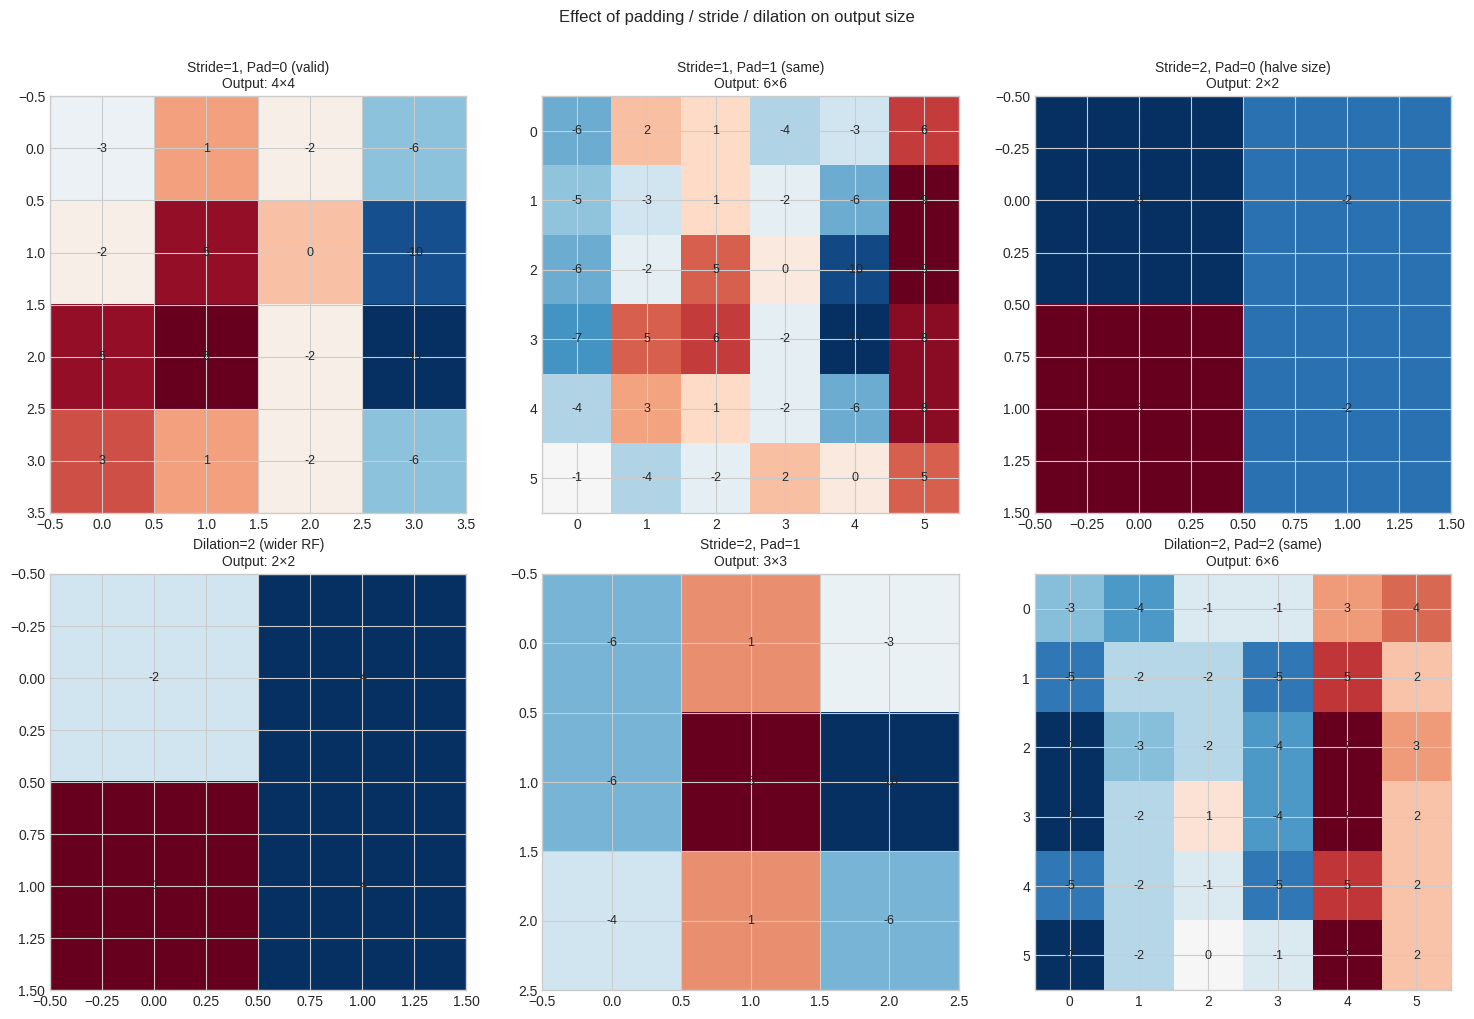

In [16]:
# Visualise padding, stride, and dilation effects
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def show_conv(ax, X, W, stride=1, padding=0, dilation=1, title=''):
    # Manual padded input
    if padding > 0:
        X_p = np.pad(X, padding)
    else:
        X_p = X.copy()
    k = W.shape[0]
    H_p, W_p = X_p.shape
    H_out = output_size(X.shape[0], k, p=padding, s=stride, d=dilation)
    Y = np.zeros((H_out, H_out))
    for i in range(H_out):
        for j in range(H_out):
            val = 0
            for m in range(k):
                for n in range(k):
                    ri = i*stride + m*dilation
                    ci = j*stride + n*dilation
                    if 0 <= ri < H_p and 0 <= ci < W_p:
                        val += X_p[ri, ci] * W[m, n]
            Y[i, j] = val
    im = ax.imshow(Y, cmap='RdBu_r', aspect='equal')
    for ii in range(H_out):
        for jj in range(H_out):
            ax.text(jj, ii, f'{Y[ii,jj]:.0f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'{title}\nOutput: {H_out}×{H_out}', fontsize=10)
    return Y

X_demo = np.random.randint(0, 4, (6, 6)).astype(float)
W_demo = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=float)

show_conv(axes[0,0], X_demo, W_demo, stride=1, padding=0, title='Stride=1, Pad=0 (valid)')
show_conv(axes[0,1], X_demo, W_demo, stride=1, padding=1, title='Stride=1, Pad=1 (same)')
show_conv(axes[0,2], X_demo, W_demo, stride=2, padding=0, title='Stride=2, Pad=0 (halve size)')
show_conv(axes[1,0], X_demo, W_demo, stride=1, padding=0, dilation=2, title='Dilation=2 (wider RF)')
show_conv(axes[1,1], X_demo, W_demo, stride=2, padding=1, title='Stride=2, Pad=1')
show_conv(axes[1,2], X_demo, W_demo, stride=1, padding=2, dilation=2, title='Dilation=2, Pad=2 (same)')

plt.suptitle('Effect of padding / stride / dilation on output size', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 5. Code Layer 1 — NumPy from Scratch

In [17]:
def conv2d_scratch(X, W, b=None, stride=1, padding=0):
    """
    2D convolution from scratch.
    X: (N, C_in, H, W)   — batch of images
    W: (C_out, C_in, kH, kW) — filter bank
    b: (C_out,)           — bias
    Returns: Y (N, C_out, H_out, W_out)
    """
    N, C_in, H, W_in = X.shape
    C_out, _, kH, kW = W.shape

    # Pad input
    if padding > 0:
        X = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)))

    H_out = (X.shape[2] - kH) // stride + 1
    W_out = (X.shape[3] - kW) // stride + 1
    Y     = np.zeros((N, C_out, H_out, W_out))

    for n in range(N):
        for co in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    # Extract patch across all input channels
                    patch = X[n, :, i*stride:i*stride+kH, j*stride:j*stride+kW]
                    # Dot product with filter co
                    Y[n, co, i, j] = np.sum(patch * W[co]) + (b[co] if b is not None else 0)
    return Y

# Test and verify against PyTorch
np.random.seed(0)
N, C_in, H_in, C_out, k = 2, 3, 8, 4, 3

X_np  = np.random.randn(N, C_in, H_in, H_in)
W_np  = np.random.randn(C_out, C_in, k, k)
b_np  = np.random.randn(C_out)

Y_np  = conv2d_scratch(X_np, W_np, b_np, stride=1, padding=1)

# PyTorch reference
conv_pt = nn.Conv2d(C_in, C_out, k, stride=1, padding=1, bias=True)
with torch.no_grad():
    conv_pt.weight.copy_(torch.tensor(W_np, dtype=torch.float32))
    conv_pt.bias.copy_(torch.tensor(b_np, dtype=torch.float32))
Y_pt = conv_pt(torch.tensor(X_np, dtype=torch.float32)).detach().numpy()

max_diff = np.max(np.abs(Y_np - Y_pt))
print('conv2d_scratch vs PyTorch nn.Conv2d:')
print(f'  Input shape:  {X_np.shape}')
print(f'  Kernel shape: {W_np.shape}')
print(f'  Output shape: {Y_np.shape}')
print(f'  Max diff:     {max_diff:.2e}  {"✓" if max_diff < 1e-4 else "✗"}')


conv2d_scratch vs PyTorch nn.Conv2d:
  Input shape:  (2, 3, 8, 8)
  Kernel shape: (4, 3, 3, 3)
  Output shape: (2, 4, 8, 8)
  Max diff:     3.07e-06  ✓


## 6. Code Layer 2 — PyTorch `nn.Conv2d`

In [18]:
# nn.Conv2d full API and usage
print('=== nn.Conv2d — all parameters ===')

# nn.Conv2d(
#   in_channels,    # C_in
#   out_channels,   # C_out
#   kernel_size,    # k or (kH, kW)
#   stride=1,       # s or (sH, sW)
#   padding=0,      # p or 'same' or 'valid'
#   dilation=1,     # d
#   groups=1,       # for depthwise convolution
#   bias=True       # learnable bias
# )

# Inspect what nn.Conv2d contains
conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
print(f'Conv2d(3, 16, 3, padding=1):')
print(f'  weight shape: {conv.weight.shape}  (C_out, C_in, kH, kW)')
print(f'  bias shape:   {conv.bias.shape}    (C_out,)')
print(f'  total params: {conv.weight.numel() + conv.bias.numel()}')

# Test various configurations
x = torch.randn(1, 3, 32, 32)
configs_conv = [
    nn.Conv2d(3, 16, 3, padding=0),      # valid
    nn.Conv2d(3, 16, 3, padding=1),      # same
    nn.Conv2d(3, 16, 3, stride=2, padding=1),  # downsample
    nn.Conv2d(3, 16, 3, dilation=2, padding=2),# dilated same
    nn.Conv2d(3, 3, 3, groups=3, padding=1),   # depthwise
]
labels = ['valid', 'same', 'stride=2', 'dilated', 'depthwise']
print()
print(f'{'Config':<12}  {'In shape':>12}  {'Out shape':>12}  {'Params':>8}')
for cfg, lbl in zip(configs_conv, labels):
    out = cfg(x)
    n_p = sum(p.numel() for p in cfg.parameters())
    print(f'{lbl:<12}  {str(x.shape):>12}  {str(out.shape):>12}  {n_p:>8}')


=== nn.Conv2d — all parameters ===
Conv2d(3, 16, 3, padding=1):
  weight shape: torch.Size([16, 3, 3, 3])  (C_out, C_in, kH, kW)
  bias shape:   torch.Size([16])    (C_out,)
  total params: 448

Config            In shape     Out shape    Params
valid         torch.Size([1, 3, 32, 32])  torch.Size([1, 16, 30, 30])       448
same          torch.Size([1, 3, 32, 32])  torch.Size([1, 16, 32, 32])       448
stride=2      torch.Size([1, 3, 32, 32])  torch.Size([1, 16, 16, 16])       448
dilated       torch.Size([1, 3, 32, 32])  torch.Size([1, 16, 32, 32])       448
depthwise     torch.Size([1, 3, 32, 32])  torch.Size([1, 3, 32, 32])        30


In [19]:
# Build and train a small CNN on FashionMNIST-style synthetic data
from torch.utils.data import DataLoader, TensorDataset

# Synthetic image data (grayscale 28×28, 4 classes)
torch.manual_seed(42)
N_train, N_test = 1000, 200
X_img_tr = torch.randn(N_train, 1, 28, 28)
X_img_te = torch.randn(N_test,  1, 28, 28)
# Add class-specific signal
y_img_tr = torch.randint(0, 4, (N_train,))
y_img_te = torch.randint(0, 4, (N_test,))
for c in range(4):
    mask = y_img_tr == c
    X_img_tr[mask, 0, c*6:(c+1)*6, c*6:(c+1)*6] += 3.0  # class-specific pattern

train_dl = DataLoader(TensorDataset(X_img_tr, y_img_tr), batch_size=64, shuffle=True)
test_dl  = DataLoader(TensorDataset(X_img_te, y_img_te), batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28×28 → 28×28
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 14×14 → 14×14
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)  # 7×7 → 7×7
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(64 * 3 * 3, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28→14
        x = self.pool(F.relu(self.conv2(x)))  # 14→7
        x = self.pool(F.relu(self.conv3(x)))  # 7→3
        x = x.flatten(1)
        return self.fc(x)

model_cnn = SimpleCNN().to(device)
print(f'SimpleCNN params: {sum(p.numel() for p in model_cnn.parameters()):,}')

opt_cnn  = optim.Adam(model_cnn.parameters(), lr=1e-3)
crit_cnn = nn.CrossEntropyLoss()

tr_losses_cnn, val_accs_cnn = [], []
for epoch in range(30):
    model_cnn.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt_cnn.zero_grad()
        crit_cnn(model_cnn(xb), yb).backward()
        opt_cnn.step()
    model_cnn.eval()
    with torch.no_grad():
        tr_losses_cnn.append(crit_cnn(model_cnn(X_img_tr.to(device)), y_img_tr.to(device)).item())
        val_accs_cnn.append((model_cnn(X_img_te.to(device)).argmax(1)==y_img_te.to(device)).float().mean().item())

print(f'Final val accuracy: {val_accs_cnn[-1]:.4f}')


SimpleCNN params: 25,604
Final val accuracy: 0.2700


## 7. Receptive Field

The **receptive field** of a neuron is the region of the input image that can affect its activation. Understanding receptive fields is critical for:
- Choosing network depth (larger objects need larger receptive fields)
- Understanding what each neuron 'sees'
- Diagnosing why shallow networks miss global features

### Receptive field growth with depth

With kernel size $k$ and stride 1 throughout:

$$RF_l = RF_{l-1} + (k-1)$$

For a network with $L$ layers all using $k \times k$ kernels with stride 1:

$$RF_L = 1 + L \cdot (k-1)$$

For $k=3$, $L=10$: $RF = 1 + 10 \times 2 = 21 \times 21$.

### Effective receptive field with stride and pooling

Each stride-2 operation doubles the receptive field growth per layer. After $s$ stride-2 operations:

$$RF_{\text{effective}} \approx RF \times 2^s$$

### Why two 3×3 layers beat one 5×5 layer

Two 3×3 conv layers have the **same receptive field** as one 5×5 layer, but:
- 2 × 3×3 = 18 parameters per channel-pair vs 5×5 = 25
- Two non-linearities vs one → more expressiveness
- This is the key design principle of VGGNet


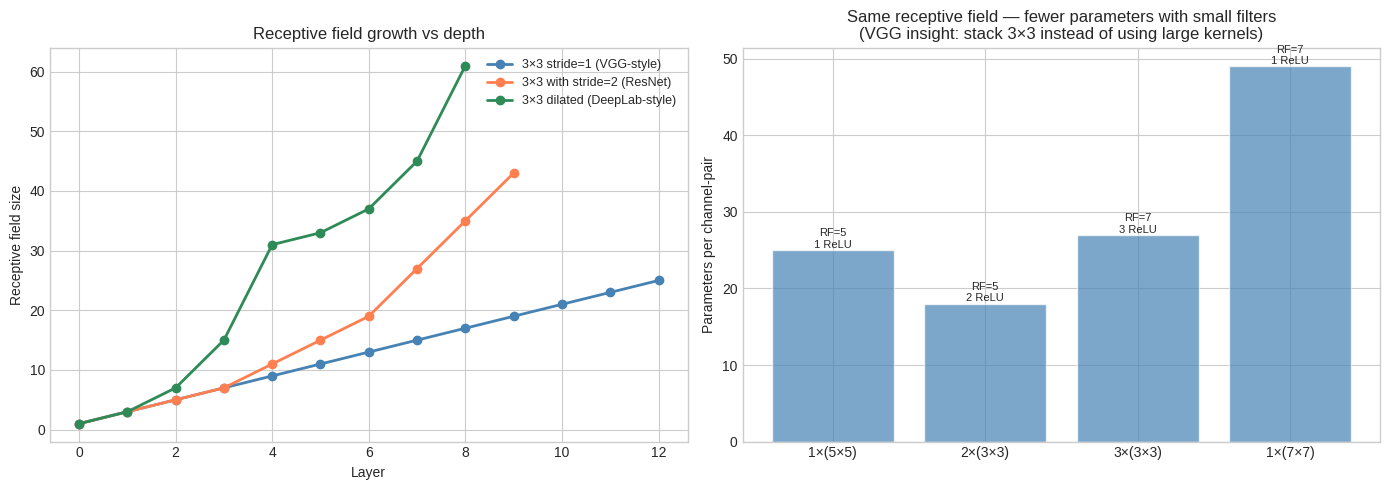

Key insight: 2×(3×3) = same RF as 1×(5×5), but 28% fewer params and 2× more non-linearities


In [20]:
# Visualise receptive field growth
def compute_receptive_field(layers):
    """
    Compute receptive field after each layer.
    layers: list of (kernel_size, stride, dilation) tuples
    """
    rf = 1
    total_stride = 1
    history = [(0, 1, 1)]  # (layer, rf, total_stride)
    for l, (k, s, d) in enumerate(layers, 1):
        rf += total_stride * (d * (k - 1))  # effective kernel expansion
        total_stride *= s
        history.append((l, rf, total_stride))
    return history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Architecture 1: all 3×3, stride=1 (deep, small RF growth)
layers_3x3 = [(3, 1, 1)] * 12
# Architecture 2: 3×3 with periodic stride=2
layers_stride = [(3,1,1),(3,1,1),(3,2,1),(3,1,1),(3,1,1),(3,2,1),(3,1,1),(3,1,1),(3,2,1)]
# Architecture 3: dilated convolutions
layers_dilated = [(3,1,1),(3,1,2),(3,1,4),(3,1,8),(3,1,1),(3,1,2),(3,1,4),(3,1,8)]

for label, layers, color in [
    ('3×3 stride=1 (VGG-style)',     layers_3x3,    'steelblue'),
    ('3×3 with stride=2 (ResNet)',   layers_stride,  'coral'),
    ('3×3 dilated (DeepLab-style)',  layers_dilated, 'seagreen'),
]:
    hist = compute_receptive_field(layers)
    ls, rfs, _ = zip(*hist)
    axes[0].plot(ls, rfs, 'o-', color=color, lw=2, label=label)

axes[0].set_title('Receptive field growth vs depth')
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Receptive field size')
axes[0].legend(fontsize=9)

# Two 3×3 vs one 5×5 comparison
data = {
    '1×(5×5)':     {'params': 25, 'rf': 5, 'nonlin': 1},
    '2×(3×3)':     {'params': 18, 'rf': 5, 'nonlin': 2},
    '3×(3×3)':     {'params': 27, 'rf': 7, 'nonlin': 3},
    '1×(7×7)':     {'params': 49, 'rf': 7, 'nonlin': 1},
}
x_pos = np.arange(len(data))
params_vals  = [v['params']  for v in data.values()]
nonlin_vals  = [v['nonlin']  for v in data.values()]

ax2 = axes[1]
bars = ax2.bar(x_pos, params_vals, color='steelblue', alpha=0.7, edgecolor='white', label='Params per channel-pair')
ax2.set_xticks(x_pos); ax2.set_xticklabels(list(data.keys()))
ax2.set_title('Same receptive field — fewer parameters with small filters\n(VGG insight: stack 3×3 instead of using large kernels)')
ax2.set_ylabel('Parameters per channel-pair')
for bar, nlin in zip(bars, nonlin_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'RF={list(data.values())[list(data.keys()).index(ax2.get_xticklabels()[int(bar.get_x()+0.5)].get_text() if bar.get_x()+0.5 < len(data) else 0)]["rf"]}\n{nlin} ReLU',
             ha='center', fontsize=8)

plt.tight_layout(); plt.show()

print('Key insight: 2×(3×3) = same RF as 1×(5×5), but 28% fewer params and 2× more non-linearities')


## 8. Visualising Learned Filters

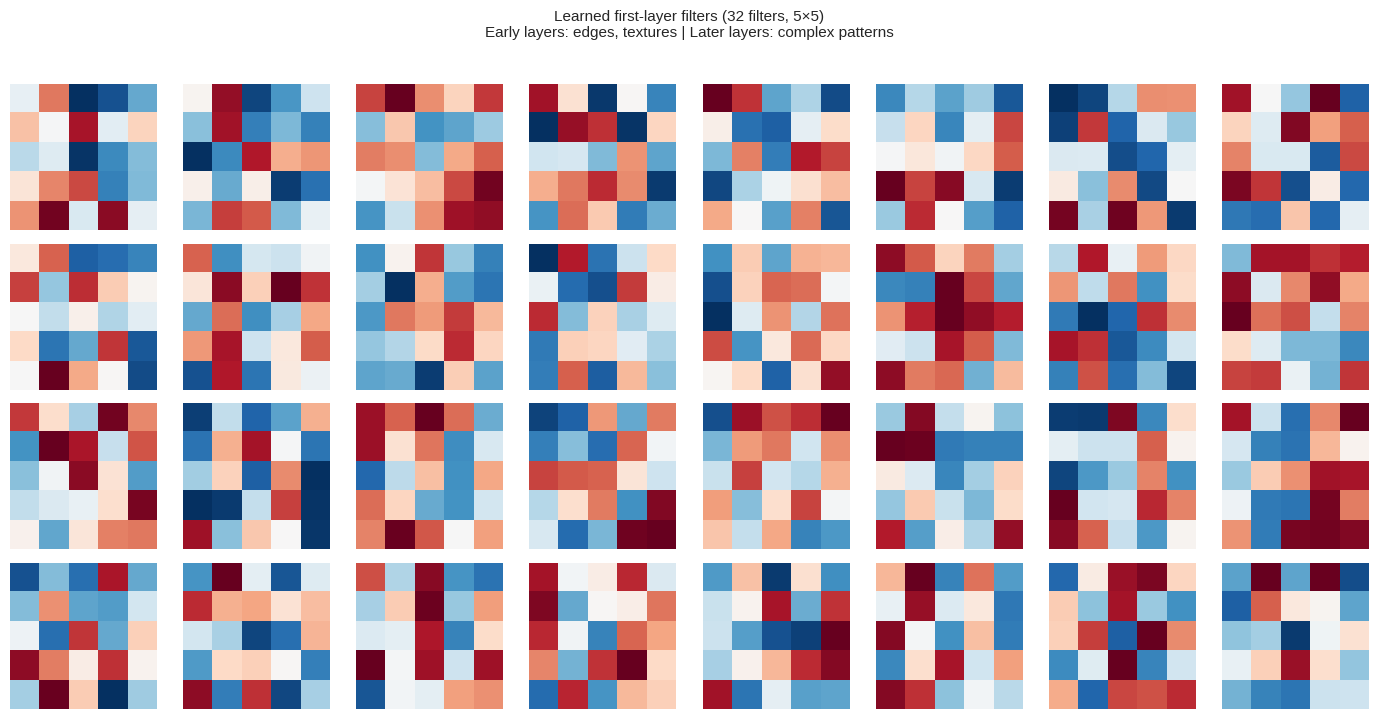

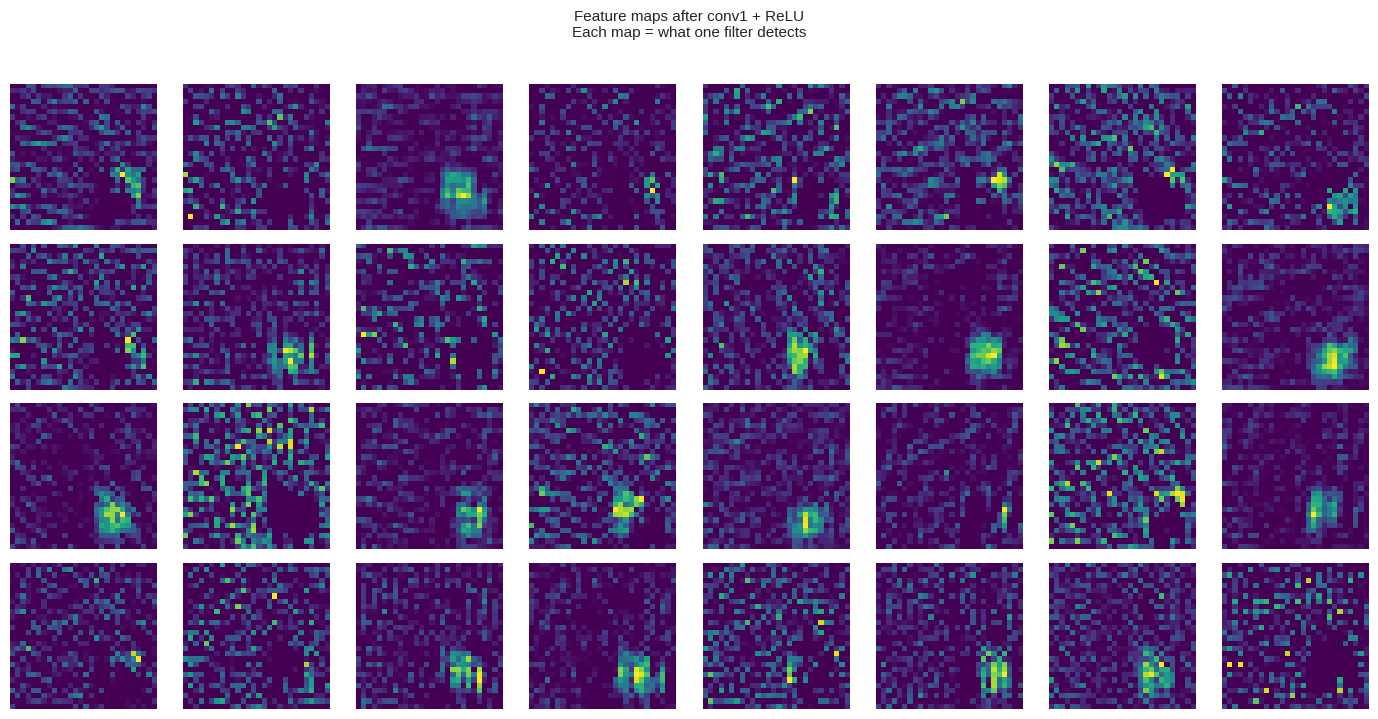

In [21]:
# What do learned filters look like?
# Use a trained model and visualise its first-layer filters

# Train a slightly larger CNN to get more interesting filters
class FilterCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 5, padding=2)  # large-ish kernel for visibility
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc    = nn.Linear(64*7*7, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return self.fc(x.flatten(1))

torch.manual_seed(0)
model_filt = FilterCNN().to(device)
opt_filt   = optim.Adam(model_filt.parameters(), lr=1e-3)
for epoch in range(50):
    model_filt.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt_filt.zero_grad()
        crit_cnn(model_filt(xb), yb).backward()
        opt_filt.step()

# Visualise first-layer filters
filters = model_filt.conv1.weight.detach().cpu().numpy()  # (32, 1, 5, 5)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for ax, f in zip(axes.ravel(), filters):
    f_show = f[0]  # single input channel
    ax.imshow(f_show, cmap='RdBu_r', vmin=-np.abs(f_show).max(), vmax=np.abs(f_show).max())
    ax.axis('off')

plt.suptitle('Learned first-layer filters (32 filters, 5×5)\n'
             'Early layers: edges, textures | Later layers: complex patterns', fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

# Visualise feature maps for a specific input
x_sample = X_img_tr[0:1].to(device)
with torch.no_grad():
    feat_maps = F.relu(model_filt.conv1(x_sample))[0].cpu().numpy()  # (32, 28, 28)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for ax, fm in zip(axes.ravel(), feat_maps):
    ax.imshow(fm, cmap='viridis')
    ax.axis('off')

plt.suptitle('Feature maps after conv1 + ReLU\nEach map = what one filter detects', fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


## 9. Transposed Convolution

Transposed convolution (often called 'deconv' or 'fractional stride conv') **upsamples** feature maps. It is the transpose of a regular convolution:

$$\text{if } \mathbf{y} = W\mathbf{x} \text{ (conv)}, \text{ then transposed conv computes } W^T\mathbf{y}$$

**Not** the inverse of convolution — it has the same spatial structure as a convolution run in the other direction, but different semantics.

### Output size for transposed convolution

$$H_{\text{out}} = (H_{\text{in}} - 1) \times s - 2p + k$$

With stride=2, padding=1, kernel=2: $H_{\text{out}} = 2 \times H_{\text{in}}$ — doubles spatial size.

### Where it's used

- **Encoder-decoder architectures** (U-Net): upsample back to input resolution
- **GANs**: generator upsamples from latent vector to image
- **Semantic segmentation**: dense prediction at full resolution

### Checkerboard artefact

Transposed convolution can produce **checkerboard artefacts** if stride doesn't divide kernel size. Fix: use **bilinear upsampling followed by regular convolution** instead.


In [22]:
# Transposed convolution from scratch and PyTorch comparison
print('=== Transposed Convolution ===')

# Build a small encoder-decoder
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU())
        # Decoder — transposed convolutions
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(32+32, 16, 2, stride=2), nn.ReLU())
        self.dec1 = nn.Conv2d(16+16, 1, 1)   # 1×1 conv for final output

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)   # (1, 28, 28) → (16, 28, 28)
        e2 = self.enc2(e1)  # (16, 28, 28) → (32, 14, 14)
        e3 = self.enc3(e2)  # (32, 14, 14) → (64, 7, 7)
        # Decoder with skip connections
        d3 = self.dec3(e3)                    # (64, 7, 7) → (32, 14, 14)
        d2 = self.dec2(torch.cat([d3, e2], 1)) # skip + (64, 14,14) → (16, 28,28)
        d1 = self.dec1(torch.cat([d2, e1], 1)) # skip + (32, 28,28) → (1, 28, 28)
        return d1

unet = SimpleUNet().to(device)
x_u  = torch.randn(2, 1, 28, 28).to(device)
out_u = unet(x_u)

print(f'UNet input:  {x_u.shape}')
print(f'UNet output: {out_u.shape}  (same resolution as input!)')
print(f'UNet params: {sum(p.numel() for p in unet.parameters()):,}')

# ConvTranspose2d shapes
print('\nConvTranspose2d output sizes:')
for (k, s, p) in [(2,2,0), (4,2,1), (3,2,1)]:
    ct = nn.ConvTranspose2d(1, 1, k, stride=s, padding=p)
    x_t = torch.randn(1, 1, 7, 7)
    print(f'  k={k} s={s} p={p}: {x_t.shape} → {ct(x_t).shape}')


=== Transposed Convolution ===
UNet input:  torch.Size([2, 1, 28, 28])
UNet output: torch.Size([2, 1, 28, 28])  (same resolution as input!)
UNet params: 35,665

ConvTranspose2d output sizes:
  k=2 s=2 p=0: torch.Size([1, 1, 7, 7]) → torch.Size([1, 1, 14, 14])
  k=4 s=2 p=1: torch.Size([1, 1, 7, 7]) → torch.Size([1, 1, 14, 14])
  k=3 s=2 p=1: torch.Size([1, 1, 7, 7]) → torch.Size([1, 1, 13, 13])


## 10. Depthwise Separable Convolution

**Paper:** Howard et al. — MobileNets (2017)

Standard convolution: one filter operates across ALL input channels simultaneously.
Depthwise separable convolution splits this into two steps:

**Step 1 — Depthwise convolution:**
Apply one filter per input channel independently (no cross-channel mixing):

$$Y_{\text{dw}}[c, i, j] = \sum_{m,n} X[c, i+m, j+n] \cdot W_{\text{dw}}[c, m, n]$$

**Step 2 — Pointwise convolution ($1 \times 1$ conv):**
Mix the channels:

$$Y_{\text{pw}}[c_{\text{out}}, i, j] = \sum_{c_{\text{in}}} Y_{\text{dw}}[c_{\text{in}}, i, j] \cdot W_{\text{pw}}[c_{\text{out}}, c_{\text{in}}]$$

### Parameter reduction

| Type | Parameters | Reduction |
|---|---|---|
| Standard Conv | $C_{\text{in}} \times C_{\text{out}} \times k^2$ | 1× |
| Depthwise Sep. | $C_{\text{in}} \times k^2 + C_{\text{in}} \times C_{\text{out}}$ | $\approx k^2$ times fewer |

For $k=3$, $C_{\text{in}} = C_{\text{out}} = 64$: standard = 36,864 params, depthwise sep. = 576 + 4,096 = 4,672 params → **8× fewer**.

Used in: MobileNet, Xception, EfficientNet, many edge deployment models.


In [23]:
class DepthwiseSeparableConv(nn.Module):
    """Depthwise separable convolution = depthwise + pointwise."""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        # Depthwise: one filter per channel (groups=in_channels)
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size, stride, padding,
            groups=in_channels, bias=False  # groups=C_in → one filter per channel
        )
        # Pointwise: 1×1 conv for channel mixing
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))

# Parameter comparison
C_in = C_out = 64; k = 3

std_conv  = nn.Conv2d(C_in, C_out, k, padding=1, bias=False)
dws_conv  = DepthwiseSeparableConv(C_in, C_out, k, padding=1)

p_std = sum(p.numel() for p in std_conv.parameters())
p_dws = sum(p.numel() for p in dws_conv.parameters())

print(f'Standard Conv2d ({C_in}→{C_out}, k={k}): {p_std:,} parameters')
print(f'Depthwise Sep Conv:                      {p_dws:,} parameters')
print(f'Parameter reduction:                     {p_std/p_dws:.1f}×')

# Verify same I/O shape
x_ds = torch.randn(2, C_in, 16, 16)
out_std = std_conv(x_ds)
out_dws = dws_conv(x_ds)
print(f'\nInput:  {x_ds.shape}')
print(f'Std:    {out_std.shape}')
print(f'DWS:    {out_dws.shape}')

# Build a tiny MobileNet-style block
class MobileNetBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = DepthwiseSeparableConv(channels, channels, 3, padding=1)
        self.bn   = nn.BatchNorm2d(channels)
        self.act  = nn.ReLU6()   # ReLU6 clips at 6 for quantization friendliness

    def forward(self, x):
        return self.act(self.bn(self.conv(x))) + x   # residual connection

block = MobileNetBlock(64)
print(f'\nMobileNetBlock params: {sum(p.numel() for p in block.parameters()):,}')


Standard Conv2d (64→64, k=3): 36,864 parameters
Depthwise Sep Conv:                      4,672 parameters
Parameter reduction:                     7.9×

Input:  torch.Size([2, 64, 16, 16])
Std:    torch.Size([2, 64, 16, 16])
DWS:    torch.Size([2, 64, 16, 16])

MobileNetBlock params: 4,800


## 11. Training Dashboard

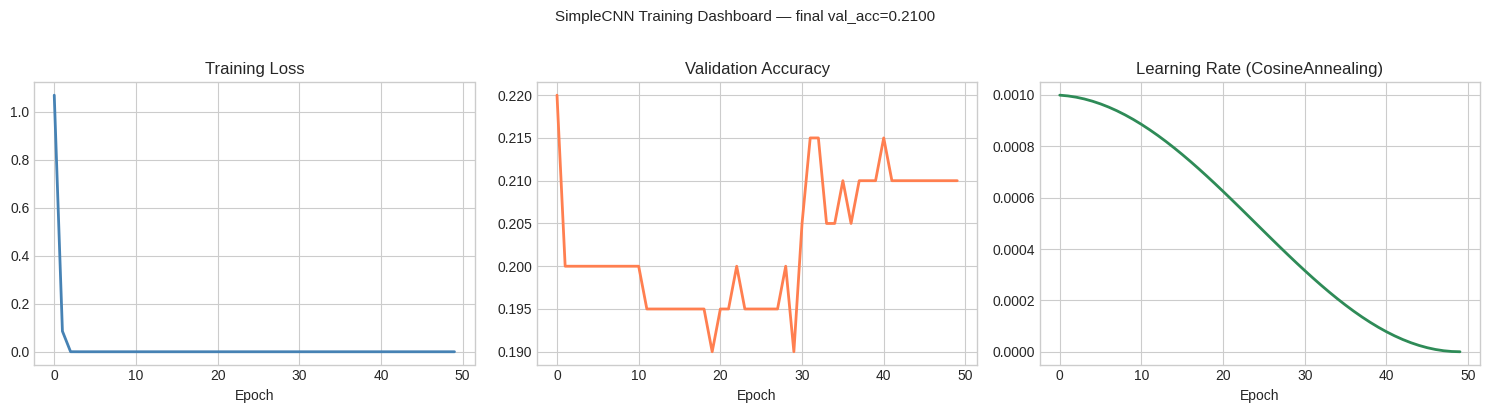

In [24]:
# Full training run with 4-panel dashboard
torch.manual_seed(0)
model_dash = SimpleCNN().to(device)
opt_dash   = optim.Adam(model_dash.parameters(), lr=1e-3)
sched_dash = optim.lr_scheduler.CosineAnnealingLR(opt_dash, T_max=50)

hist_dash = {'tr_loss':[], 'val_acc':[], 'lr':[]}
for epoch in range(50):
    model_dash.train()
    ep_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt_dash.zero_grad()
        loss_d = crit_cnn(model_dash(xb), yb)
        loss_d.backward(); opt_dash.step()
        ep_loss += loss_d.item()
    sched_dash.step()
    model_dash.eval()
    with torch.no_grad():
        vacc = (model_dash(X_img_te.to(device)).argmax(1)==y_img_te.to(device)).float().mean().item()
    hist_dash['tr_loss'].append(ep_loss/len(train_dl))
    hist_dash['val_acc'].append(vacc)
    hist_dash['lr'].append(sched_dash.get_last_lr()[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_dash['tr_loss'], color='steelblue', lw=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(hist_dash['val_acc'], color='coral', lw=2)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(hist_dash['lr'], color='seagreen', lw=2)
axes[2].set_title('Learning Rate (CosineAnnealing)'); axes[2].set_xlabel('Epoch')

plt.suptitle(f'SimpleCNN Training Dashboard — final val_acc={hist_dash["val_acc"][-1]:.4f}',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


## 12. Debugging Section

In [25]:
# Bug 1: Wrong number of channels — shape mismatch
print('=== Bug 1: Channel mismatch ===')

conv_a = nn.Conv2d(3, 16, 3)   # expects 3 input channels
x_wrong = torch.randn(2, 1, 28, 28)  # only 1 channel!

try:
    out = conv_a(x_wrong)
except RuntimeError as e:
    print(f'Error: {str(e)[:100]}')
    print('Fix: x.shape[1] must equal conv.in_channels')

x_right = torch.randn(2, 3, 28, 28)  # correct: 3 channels
out = conv_a(x_right)
print(f'Correct: {x_right.shape} → {out.shape}')


=== Bug 1: Channel mismatch ===
Error: Given groups=1, weight of size [16, 3, 3, 3], expected input[2, 1, 28, 28] to have 3 channels, but g
Fix: x.shape[1] must equal conv.in_channels
Correct: torch.Size([2, 3, 28, 28]) → torch.Size([2, 16, 26, 26])


In [26]:
# Bug 2: Not flattening correctly before linear layer
print('=== Bug 2: Wrong flatten before fc layer ===')

class BuggyFlatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc   = nn.Linear(16 * 14 * 14, 4)  # correct spatial size

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))  # (B, 16, 14, 14)
        x = x.view(x.size(0), -1)            # correct: (B, 16*14*14)
        return self.fc(x)

class BuggyFlatten2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc   = nn.Linear(16 * 14 * 14, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))  # (B, 16, 14, 14)
        # BUG: wrong flatten — flattens everything including batch
        x = x.view(-1)  # becomes (B*16*14*14,) — wrong!
        return self.fc(x.unsqueeze(0))  # fails

x_fl = torch.randn(2, 1, 28, 28)
try:
    out_ok = BuggyFlatten()(x_fl)
    print(f'Correct flatten: output shape = {out_ok.shape}')
except Exception as e:
    print(f'Error: {e}')

print('\nAlways use: x = x.view(x.size(0), -1)  or  x.flatten(1)')
print('x.size(0) = batch size, -1 = infer remaining')


=== Bug 2: Wrong flatten before fc layer ===
Correct flatten: output shape = torch.Size([2, 4])

Always use: x = x.view(x.size(0), -1)  or  x.flatten(1)
x.size(0) = batch size, -1 = infer remaining


In [27]:
# Bug 3: Using stride=2 conv then computing wrong fc input size
print('=== Bug 3: Wrong fc input size after pooling/strided conv ===')

def compute_feature_map_size(H, layers):
    """Track spatial size through a sequence of conv/pool operations."""
    print(f'Input: {H}×{H}')
    for name, cfg in layers:
        if cfg['type'] == 'conv':
            k, p, s = cfg['k'], cfg['p'], cfg['s']
            H = (H + 2*p - k) // s + 1
        elif cfg['type'] == 'pool':
            H = H // cfg['k']
        print(f'  After {name}: {H}×{H}')
    return H

H_final = compute_feature_map_size(28, [
    ('Conv2d(k=3,p=1,s=1)', {'type':'conv', 'k':3, 'p':1, 's':1}),
    ('MaxPool2d(2)',         {'type':'pool', 'k':2}),
    ('Conv2d(k=3,p=1,s=1)', {'type':'conv', 'k':3, 'p':1, 's':1}),
    ('MaxPool2d(2)',         {'type':'pool', 'k':2}),
    ('Conv2d(k=3,p=0,s=1)', {'type':'conv', 'k':3, 'p':0, 's':1}),  # no padding!
])
print(f'\nFinal feature map: {H_final}×{H_final}')
print(f'FC input size (with 64 channels): 64 × {H_final} × {H_final} = {64*H_final*H_final}')
print('\nTip: always verify spatial size using this calculation or by printing tensor.shape')
print('Use nn.AdaptiveAvgPool2d((1,1)) before fc to avoid size mismatches!')


=== Bug 3: Wrong fc input size after pooling/strided conv ===
Input: 28×28
  After Conv2d(k=3,p=1,s=1): 28×28
  After MaxPool2d(2): 14×14
  After Conv2d(k=3,p=1,s=1): 14×14
  After MaxPool2d(2): 7×7
  After Conv2d(k=3,p=0,s=1): 5×5

Final feature map: 5×5
FC input size (with 64 channels): 64 × 5 × 5 = 1600

Tip: always verify spatial size using this calculation or by printing tensor.shape
Use nn.AdaptiveAvgPool2d((1,1)) before fc to avoid size mismatches!


## 13. Exercises

**Exercise 1:** Implement a **vectorised** 2D convolution using `np.lib.stride_tricks.as_strided` to create a view of the input as a collection of patches, then use a single `np.einsum` to compute all output values at once. Compare speed against the naive nested-loop implementation on a 32×32 input with a 3×3 kernel, batch of 8, 16 channels.


In [28]:
# Your code here


In [29]:
# Solution — vectorised conv using im2col + matmul
def im2col(X, k, stride=1, padding=0):
    """
    Rearranges input patches into columns.
    X: (N, C, H, W)
    Returns: (N, C*k*k, H_out*W_out)
    """
    N, C, H, W = X.shape
    if padding > 0:
        X = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)))
    H_out = (X.shape[2] - k) // stride + 1
    W_out = (X.shape[3] - k) // stride + 1

    # Build patch matrix using sliding window view
    cols = np.zeros((N, C, k, k, H_out, W_out))
    for i in range(k):
        i_max = i + stride*H_out
        for j in range(k):
            j_max = j + stride*W_out
            cols[:, :, i, j, :, :] = X[:, :, i:i_max:stride, j:j_max:stride]
    return cols.reshape(N, C*k*k, H_out*W_out)

def conv2d_im2col(X, W, stride=1, padding=0):
    N, C_in, H, W_in = X.shape
    C_out, _, k, _ = W.shape
    H_out = (H + 2*padding - k) // stride + 1
    W_out = (W_in + 2*padding - k) // stride + 1

    cols  = im2col(X, k, stride, padding)       # (N, C_in*k*k, H_out*W_out)
    W_col = W.reshape(C_out, -1)                 # (C_out, C_in*k*k)
    Y_col = W_col @ cols                          # (N, C_out, H_out*W_out) via broadcasting
    # Actually need to handle N separately
    Y = np.einsum('ck,nkp->ncp', W_col, cols)
    return Y.reshape(N, C_out, H_out, W_out)

import time
np.random.seed(0)
N_t, C_t, H_t, k_t = 8, 16, 32, 3
X_t = np.random.randn(N_t, C_t, H_t, H_t)
W_t = np.random.randn(C_t, C_t, k_t, k_t)

t0 = time.time()
Y_naive = conv2d_scratch(X_t, W_t, stride=1, padding=1)
t_naive = time.time() - t0

t0 = time.time()
Y_fast  = conv2d_im2col(X_t, W_t, stride=1, padding=1)
t_fast  = time.time() - t0

max_diff = np.max(np.abs(Y_naive - Y_fast))
print(f'Results match: {max_diff < 1e-8}')
print(f'Naive (loops): {t_naive:.3f}s')
print(f'im2col+einsum: {t_fast:.3f}s')
print(f'Speedup: {t_naive/t_fast:.1f}×')


Results match: True
Naive (loops): 1.736s
im2col+einsum: 0.113s
Speedup: 15.4×


**Exercise 2:** Implement the **backward pass** for `conv2d_scratch`. Given upstream gradient `dL_dY` (same shape as output), compute:
- `dL_dX` (gradient w.r.t. input) — hint: this is a **full convolution** of `dL_dY` with flipped `W`
- `dL_dW` (gradient w.r.t. kernel) — hint: convolve `X` with `dL_dY` at each position

Verify both gradients with numerical differentiation.


In [30]:
# Your code here


In [31]:
# Solution
def conv2d_backward(X, W, dL_dY, stride=1, padding=0):
    """
    Backward pass for 2D convolution.
    X:     (N, C_in, H, W)
    W:     (C_out, C_in, kH, kW)
    dL_dY: (N, C_out, H_out, W_out)
    """
    N, C_in, H, W_in = X.shape
    C_out, _, kH, kW = W.shape
    H_out, W_out = dL_dY.shape[2], dL_dY.shape[3]

    # Pad X for gradient computation
    if padding > 0:
        X_pad = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)))
    else:
        X_pad = X

    dL_dW = np.zeros_like(W)
    dL_dX_pad = np.zeros_like(X_pad)

    for n in range(N):
        for co in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    # dL/dW[co] += dL_dY[n,co,i,j] * X_patch
                    patch = X_pad[n, :, i*stride:i*stride+kH, j*stride:j*stride+kW]
                    dL_dW[co] += dL_dY[n, co, i, j] * patch
                    # dL/dX_patch += dL_dY[n,co,i,j] * W[co]
                    dL_dX_pad[n, :, i*stride:i*stride+kH, j*stride:j*stride+kW] += \
                        dL_dY[n, co, i, j] * W[co]

    # Remove padding from dL_dX
    if padding > 0:
        dL_dX = dL_dX_pad[:, :, padding:-padding, padding:-padding]
    else:
        dL_dX = dL_dX_pad

    return dL_dX, dL_dW

# Verify
np.random.seed(1)
N_v, C_in_v, H_v, C_out_v, k_v = 2, 2, 6, 3, 3
X_v = np.random.randn(N_v, C_in_v, H_v, H_v)
W_v = np.random.randn(C_out_v, C_in_v, k_v, k_v)

Y_v   = conv2d_scratch(X_v, W_v, padding=1)
dL_dY = np.random.randn(*Y_v.shape)
dL_dX, dL_dW = conv2d_backward(X_v, W_v, dL_dY, padding=1)

# Numerical check for dL/dX
h_num = 1e-5
dL_dX_num = np.zeros_like(X_v)
for i in range(N_v):
    for j in range(C_in_v):
        for r in range(H_v):
            for c in range(H_v):
                Xp = X_v.copy(); Xp[i,j,r,c]+=h_num
                Xm = X_v.copy(); Xm[i,j,r,c]-=h_num
                Yp = conv2d_scratch(Xp,W_v,padding=1)
                Ym = conv2d_scratch(Xm,W_v,padding=1)
                dL_dX_num[i,j,r,c] = ((Yp-Ym)*dL_dY/(2*h_num)).sum()

rel_err_X = np.linalg.norm(dL_dX-dL_dX_num)/(np.linalg.norm(dL_dX)+np.linalg.norm(dL_dX_num)+1e-12)
print(f'dL/dX relative error: {rel_err_X:.2e}  {"✓" if rel_err_X<1e-4 else "✗"}')


dL/dX relative error: 7.98e-12  ✓


**Exercise 3:** Build a **Squeeze-and-Excitation (SE) block** — a lightweight attention mechanism for CNNs from the SE-Net paper (Hu et al. 2018):

1. **Squeeze:** Global average pool: $(N, C, H, W) \to (N, C)$
2. **Excitation:** Two FC layers with bottleneck: $C \to C/r \to C$, sigmoid output
3. **Scale:** Multiply channel-wise: output $= x \odot \text{excitation}$

Implement as `nn.Module`. Wrap a standard conv block with SE. Show that SE improves accuracy on the synthetic dataset.


In [32]:
# Your code here


In [33]:
# Solution
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block — channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.squeeze   = nn.AdaptiveAvgPool2d(1)   # Global Average Pool
        self.excitation = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (N, C, H, W)
        s = self.squeeze(x)           # (N, C, 1, 1)
        e = self.excitation(s)        # (N, C)
        e = e.unsqueeze(-1).unsqueeze(-1)  # (N, C, 1, 1)
        return x * e                  # channel-wise scaling

class SEConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, padding=k//2)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.se   = SEBlock(out_ch)

    def forward(self, x):
        return self.se(F.relu(self.bn(self.conv(x))))

class SENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            SEConvBlock(1, 16), nn.MaxPool2d(2),
            SEConvBlock(16, 32), nn.MaxPool2d(2),
            SEConvBlock(32, 64), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(64, 4)

    def forward(self, x):
        return self.fc(self.features(x).flatten(1))

# Compare SimpleCNN vs SENet
for ModelClass, name in [(SimpleCNN, 'SimpleCNN'), (SENet, 'SENet')]:
    torch.manual_seed(0)
    m = ModelClass().to(device)
    opt_se = optim.Adam(m.parameters(), lr=1e-3)
    for ep in range(30):
        m.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt_se.zero_grad()
            crit_cnn(m(xb), yb).backward()
            opt_se.step()
    m.eval()
    with torch.no_grad():
        acc = (m(X_img_te.to(device)).argmax(1)==y_img_te.to(device)).float().mean().item()
        n_p = sum(p.numel() for p in m.parameters())
    print(f'{name:<12}: acc={acc:.4f}  params={n_p:,}')


SimpleCNN   : acc=0.2050  params=25,604
SENet       : acc=0.2000  params=26,608


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
